# 03 · Shaping a basis: piston, removed modes, orthogonality, normalization

**Who this is for:** you've picked a basis and now need it to fit your system. That might mean no piston, no tip/tilt (because a separate mirror handles them), no waffle, orthonormal modes for a clean reconstructor, or a particular scale for your DM's stroke.

Every generator applies the same steps, in this order:

```
raw modes ──► remove piston / other modes ──► orthonormalize ──► normalize ──► M2C
             ignore_piston=, remove=          orthonormalize=    normalize=
```

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import aobasis

plt.rcParams["figure.dpi"] = 80
positions = aobasis.make_circular_actuator_grid(telescope_diameter=10.0, grid_size=20)
x, y = positions.T
zern = aobasis.ZernikeBasisGenerator(positions, pupil_radius=5.0)

## 1. Piston

A wavefront sensor measures phase *differences*, so it can't see piston, a constant offset over the pupil. Controlling piston only wastes stroke. `ignore_piston=True` keeps it out.

Leaving out the j = 1 term isn't enough. On a discrete grid the other Zernikes aren't exactly zero-mean either. Defocus, for example, averages slightly off zero over 276 points:

In [2]:
raw = zern.generate(10)[:, 1:]  # Noll j = 2..10, piston dropped by hand
clean = zern.generate(9, ignore_piston=True)  # piston removed properly

print("largest |mean| / RMS, dropping j=1 by hand:", np.abs(raw.mean(0) / raw.std(0)).max().round(4))
print("largest |mean| / RMS, ignore_piston=True:   ", np.abs(clean.mean(0) / clean.std(0)).max().round(12))

largest |mean| / RMS, dropping j=1 by hand: 0.0475
largest |mean| / RMS, ignore_piston=True:    0.0


`ignore_piston=True` subtracts each mode's mean (Zernike, Fourier, Hadamard). For KL it diagonalizes the piston-removed turbulence covariance. Either way, every mode is exactly zero-mean.

## 2. Removing other modes: tip/tilt, waffle, anything

`remove=` generalizes this to any modes you want kept out of the basis. Typical reasons:

- **A separate tip/tilt mirror** handles tip/tilt, so the DM basis shouldn't include them: `remove="tiptilt"`.
- **Waffle**, the checkerboard pattern a Fried-geometry Shack-Hartmann can't see, should never be commanded.
- **Another loop** already controls some modes.

`remove` takes names (`"piston"`, `"tip"`, `"tilt"`, `"tiptilt"`), arrays of shape `(n_actuators,)` or `(n_actuators, k)`, or a list mixing them:

largest |overlap| with piston, tip, tilt, waffle: 0.0


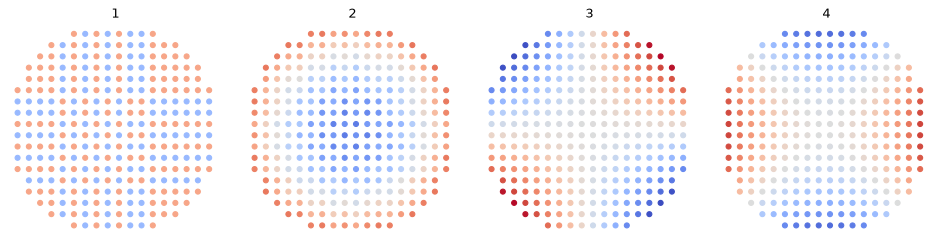

In [3]:
waffle = np.cos(np.pi * np.round(x / (10.0 / 19))) * np.cos(np.pi * np.round(y / (10.0 / 19)))

modes = zern.generate(10, ignore_piston=True, remove=["tiptilt", waffle])
blocked = np.column_stack([np.ones_like(x), x, y, waffle])
print("largest |overlap| with piston, tip, tilt, waffle:", np.abs(blocked.T @ modes).max().round(12))

aobasis.plot_basis_modes(np.column_stack([waffle, modes[:, :3]]), positions, count=4, title_prefix="")

The first panel is the waffle pattern, the next three the first modes left over. Zernikes that lie *inside* the removed space (tip and tilt here) are skipped, so the first mode left is defocus. The others have the removed modes projected out.

For KL, `remove=` diagonalizes the turbulence covariance with those modes taken out. You get the optimal basis for the turbulence the DM still has to correct.

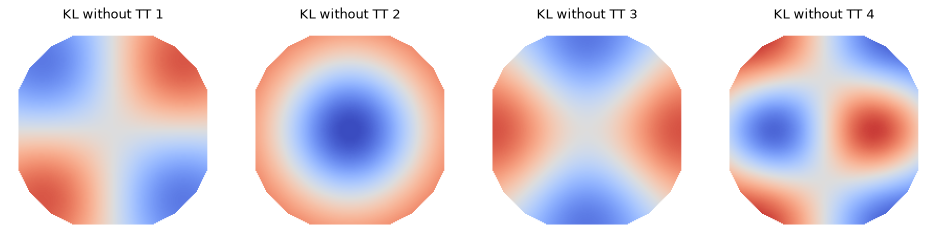

In [4]:
kl = aobasis.KLBasisGenerator(positions)
kl.generate(8, ignore_piston=True, remove="tiptilt")
kl.plot(count=4, title_prefix="KL without TT", interpolate=True)

Outside a generator, `aobasis.project_out(modes, subspace)` does the projection on any matrix.

## 3. Orthonormalization

Zernikes are orthogonal over the continuous disk but not over 276 points. The Gram matrix (mode overlaps) shows the cross-talk: the faint off-diagonal entries, up to about 0.3, pair modes with the same angular frequency.

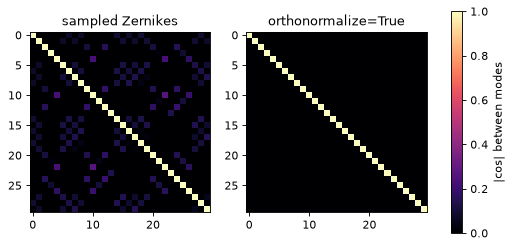

In [5]:
z = zern.generate(30, ignore_piston=True)
zo = zern.generate(30, ignore_piston=True, orthonormalize=True)

def gram(m):
    u = m / np.linalg.norm(m, axis=0)
    return np.abs(u.T @ u)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
for ax, m, title in zip(axes, (z, zo), ("sampled Zernikes", "orthonormalize=True")):
    im = ax.imshow(gram(m), vmin=0, vmax=1, cmap="magma")
    ax.set_title(title)
fig.colorbar(im, ax=axes, label="|cos| between modes")
plt.show()

`orthonormalize=True` runs Gram-Schmidt in order, so each mode stays as close as possible to its original. Mode `k` spans the same space as the first `k` raw modes, and still looks like "the k-th Zernike":

In [6]:
corr = np.sum(z * zo, axis=0) / np.linalg.norm(z, axis=0)
print("correlation of each orthonormalized mode with its raw Zernike:", corr.min().round(3), "to", corr.max().round(3))

correlation of each orthonormalized mode with its raw Zernike: 0.898 to 1.0


Orthonormal modes make reconstructors simpler (C2M = M2Cᵀ) and modal gains independent. KL and zonal modes are orthonormal already.

## 4. Normalization

Each basis comes with its own natural scale: Zernikes have unit RMS on the continuous disk, KL modes unit L2 norm, Hadamard entries ±1. `normalize=` puts every mode on a common scale, applied last:

| `normalize=` | each mode has… | use it when |
|---|---|---|
| `"rms"` | unit RMS over the actuators | coefficients should be in wavefront units (1 coefficient = 1 unit RMS) |
| `"l2"` | unit Euclidean norm | linear algebra: orthonormal bases have C2M = M2Cᵀ |
| `"peak"` | largest \|command\| = 1 | stroke-limited calibration, like a zonal poke |
| `"pv"` | peak-to-valley = 1 | specifying a P-V wavefront |

In [7]:
for how in ("rms", "l2", "peak", "pv"):
    m = zern.generate(5, ignore_piston=True, normalize=how)
    sizes = {
        "rms": np.sqrt(np.mean(m**2, 0)),
        "l2": np.linalg.norm(m, axis=0),
        "peak": np.abs(m).max(0),
        "pv": np.ptp(m, axis=0),
    }[how]
    print(f"{how:>4}: {np.round(sizes, 6)}")

 rms: [1. 1. 1. 1. 1.]
  l2: [1. 1. 1. 1. 1.]
peak: [1. 1. 1. 1. 1.]
  pv: [1. 1. 1. 1. 1.]


For KL, `eigenvalues` follow the normalization: they stay the variance of each mode's coefficient, which is the prior a MAP reconstructor needs.

## 5. Zernike orderings

Different communities number Zernikes differently. `ordering=` picks the convention. The modes stay the same and only their order changes, as the `(n, m)` pairs show:

In [8]:
gen = aobasis.ZernikeBasisGenerator
print("noll  :", [gen._noll_to_nm(j) for j in range(1, 9)])
print("ansi  :", [gen._ansi_to_nm(j) for j in range(0, 8)])
print("fringe:", [gen._fringe_to_nm(j) for j in range(1, 9)])
fringe = zern.generate(9, ordering="fringe")  # e.g. Z9 is primary spherical in Fringe order

noll  : [(0, 0), (1, 1), (1, -1), (2, 0), (2, -2), (2, 2), (3, -1), (3, 1)]
ansi  : [(0, 0), (1, -1), (1, 1), (2, -2), (2, 0), (2, 2), (3, -3), (3, -1)]
fringe: [(0, 0), (1, 1), (1, -1), (2, 0), (2, 2), (2, -2), (3, 1), (3, -1)]


## 6. When aobasis warns you

A `RuntimeWarning` means the basis isn't what you might assume. The usual causes:

- **Too many modes for the grid.** Highly oscillating Zernikes alias on a coarse grid, so some become linear combinations of others.
- **Fourier near full size.** Every mode is independent of the ones before it, but the raw matrix becomes ill-conditioned. `orthonormalize=True` gives an accurate orthonormal basis anyway.
- **Zernike actuators outside `pupil_radius`.** Their values are extrapolated.

In [9]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    zern.generate(len(positions))  # as many Zernikes as actuators
for w in caught:
    print(w.message)

ZernikeBasisGenerator: 276 modes have rank 246 on these 276 actuators; some modes are linearly dependent.


Use `report()` whenever you want the numbers:

In [10]:
print(zern.report())

276 modes on 276 actuators, rank 246
condition number inf
largest |cos| between two modes 0.677
piston content (|mean| / RMS): max 1
mode L2 norms 8.72 to 17.8


Finally, misspelled options are errors rather than silently ignored:

In [11]:
try:
    zern.generate(10, orthonormalise=True)
except TypeError as err:
    print("TypeError:", err)

TypeError: ZernikeBasisGenerator.generate() got an unexpected keyword argument 'orthonormalise'. Did you mean 'orthonormalize'?
